#  COVID-19 Vision Monitoring System  

**Developed as part of the Computer Vision course at IU International University of Applied Sciences.**

---

##  Overview
The **COVID-19 Vision Monitoring System** is a computer vision tool designed to monitor compliance with COVID-19 safety protocols in indoor public spaces.  
It helps users automatically:
-  Detect humans in a video stream.  
-  Identify if individuals are wearing face masks.  
-  Estimate social distancing between people.  
-  Evaluate risk levels (Safe / High Risk) based on mask usage and proximity.  
-  Save annotated videos showing mask compliance and social distance violations.

This system makes monitoring COVID-19 protocols **simple, efficient, and fully automated**.

## Human Detection

This section detects humans in the input videos.  

- **Model:** `yolov8m.pt`  
- **Functionality:** Draws bounding boxes around detected humans and counts the number of people per frame.


In [1]:
import cv2
import csv
import os
from ultralytics import YOLO

VIDEO_PATH = "videos/sample_video.mp4"  
OUTPUT_PATH = "outputs/humans_out.mp4"
STATS_PATH = "outputs/humans_stats.csv"
VIEW = True  

In [2]:
class HumanDetector:
    def __init__(self, model_name="models/yolov8m.pt", conf=0.5, iou=0.5, device=None):
        self.model = YOLO(model_name)
        self.conf = conf
        self.iou = iou
        self.device = device

    def infer_frame(self, frame):
        results = self.model.predict(
            source=frame,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            classes=[0],
            verbose=False
        )
        dets = []
        for r in results:
            if r.boxes is None or len(r.boxes) == 0:
                continue
            xyxy = r.boxes.xyxy.cpu().numpy()
            for (x1, y1, x2, y2) in xyxy:
                dets.append((int(x1), int(y1), int(x2), int(y2)))
        return dets

In [3]:
def draw_box(frame, bbox, label="Human"):
    x1, y1, x2, y2 = bbox
    color = (0, 255, 0)
    thickness = 2
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(frame, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

In [4]:
def run_video(video_path, output_path=None, stats_path=None, view=True):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open {video_path}")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h)) if output_path else None

    detector = HumanDetector()
    stats = []

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        dets = detector.infer_frame(frame)
        count = len(dets)

        for bbox in dets:
            draw_box(frame, bbox)

        cv2.putText(frame, f"People: {count}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        stats.append([frame_idx, count])

        if view:
            cv2.imshow("Humans Detection", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
        if out:
            out.write(frame)

        if frame_idx % 30 == 0:
            print(f"[INFO] Processed frame {frame_idx}, detected {count} humans.")

    cap.release()
    if out:
        out.release()
    cv2.destroyAllWindows()

    if stats_path:
        os.makedirs(os.path.dirname(stats_path), exist_ok=True)
        with open(stats_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Frame", "Human_Count"])
            writer.writerows(stats)
        print(f"[OK] Stats saved to {stats_path}")

    print("[DONE] Human detection completed.")

In [5]:
!python human_detection/human_detector.py --source "videos/sample3.mp4" --out "outputs/human_out.mp4" --view

[INFO] Processed frame 30, detected 6 humans.
[INFO] Processed frame 60, detected 6 humans.
[INFO] Processed frame 90, detected 7 humans.
[INFO] Processed frame 120, detected 8 humans.
[INFO] Processed frame 150, detected 9 humans.
[INFO] Processed frame 180, detected 8 humans.
[INFO] Processed frame 210, detected 7 humans.
[INFO] Processed frame 240, detected 7 humans.
[INFO] Processed frame 270, detected 7 humans.
[INFO] Processed frame 300, detected 10 humans.
[INFO] Processed frame 330, detected 9 humans.
[INFO] Processed frame 360, detected 11 humans.
[INFO] Processed frame 390, detected 11 humans.
[INFO] Processed frame 420, detected 11 humans.
[INFO] Processed frame 450, detected 12 humans.
[INFO] Processed frame 480, detected 13 humans.
[INFO] Processed frame 510, detected 12 humans.
[INFO] Processed frame 540, detected 13 humans.
[INFO] Processed frame 570, detected 11 humans.
[INFO] Processed frame 600, detected 11 humans.
[INFO] Processed frame 630, detected 11 humans.
[INFO

# Show an image from the resulting video 

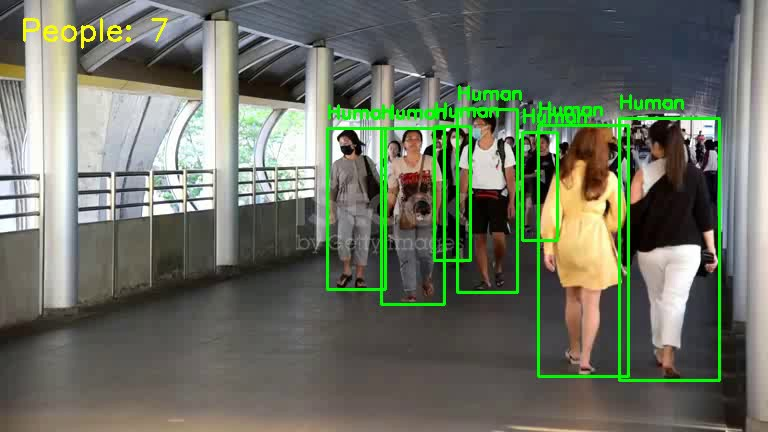

In [6]:
import cv2
from IPython.display import Image, display
import os

video_path = "outputs/human_out.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite("outputs/human_frame.jpg", frame)
    display(Image(filename="outputs/human_frame.jpg"))
else:
    print(" No frame found in the output video.")

# Reading the results table (CSV)

In [7]:
import pandas as pd

csv_path = "outputs/humans_stats.csv"
df = pd.read_csv(csv_path)
display(df.head(10)) 

,Frame,Human_Count
0,1,7
1,2,6
2,3,6
3,4,7
4,5,7
5,6,7
6,7,7
7,8,8
8,9,7
9,10,7


# A chart of the number of people

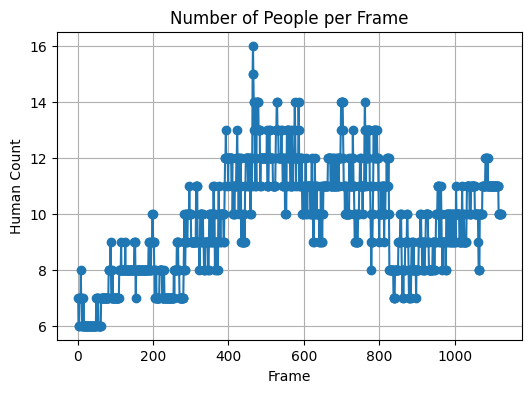

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df["Frame"], df["Human_Count"], marker='o')
plt.title("Number of People per Frame")
plt.xlabel("Frame")
plt.ylabel("Human Count")
plt.grid(True)
plt.show()


###  Mask Detection

```markdown
## Mask Detection

This section detects face masks on the people in the videos.  

- **Model:** `mask_yolov8n.pt`  
- **Functionality:** Identifies if each detected face is wearing a mask or not.


In [9]:
import cv2
from ultralytics import YOLO
import os
import csv

In [10]:
video_path = "videos/sample1.mp4"
output_video = "outputs/mask_out.mp4"
model_path = "models/mask_yolov8n.pt"
view = True
csv_path = "outputs/mask_stats.csv"
confidence = 0.5

In [11]:
class MaskDetector:
    def __init__(self, model_path=model_path):
        self.model = YOLO(model_path)

    def detect(self, frame, conf_threshold=confidence):
        results = self.model(frame)
        detections = []
        for r in results:
            for box in r.boxes:
                cls = int(box.cls[0])
                label = self.model.names[cls]
                conf = float(box.conf[0])
                if conf < conf_threshold:
                    continue
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                detections.append({
                    "label": label,
                    "confidence": conf,
                    "bbox": (int(x1), int(y1), int(x2), int(y2))
                })
        return detections


In [12]:
def draw_box(frame, bbox, label):
    x1, y1, x2, y2 = map(int, bbox)
    if "no" in label.lower():
        color = (0, 0, 255)
        text = "No Mask"
    else:
        color = (0, 255, 0)
        text = "Mask"
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    cv2.putText(frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


In [13]:
def run_video(video_path, output_video=output_video, csv_file=csv_path, view=view):
    cap = cv2.VideoCapture(video_path)
    detector = MaskDetector(model_path)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    os.makedirs(os.path.dirname(output_video), exist_ok=True)
    out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

    os.makedirs(os.path.dirname(csv_file), exist_ok=True)
    csvf = open(csv_file, mode='w', newline='')
    writer = csv.writer(csvf)
    writer.writerow(["Frame", "Total_Faces", "Mask", "No_Mask", "Mask_Percentage"])

    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        detections = detector.detect(frame)
        mask_count = sum(1 for d in detections if "no" not in d["label"].lower())
        no_mask_count = sum(1 for d in detections if "no" in d["label"].lower())
        total_faces = mask_count + no_mask_count
        mask_percentage = (mask_count / total_faces * 100) if total_faces > 0 else 0

        writer.writerow([frame_idx, total_faces, mask_count, no_mask_count, f"{mask_percentage:.2f}"])

        for det in detections:
            draw_box(frame, det["bbox"], det["label"])

        out.write(frame)
        if view:
            cv2.imshow("Mask Detection", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    out.release()
    csvf.close()
    cv2.destroyAllWindows()
    print(f"Video saved to: {output_video}")
    print(f"CSV stats saved to: {csv_file}")

In [14]:
!python -m mask_detection.mask_detector --source "videos/sample1.mp4" --out "outputs/mask_out.mp4" --view


0: 384x640 4 no-masks, 3 masks, 51.3ms
Speed: 3.1ms preprocess, 51.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no-masks, 3 masks, 41.4ms
Speed: 4.2ms preprocess, 41.4ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no-masks, 3 masks, 35.8ms
Speed: 2.7ms preprocess, 35.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no-masks, 3 masks, 36.8ms
Speed: 3.0ms preprocess, 36.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no-masks, 3 masks, 37.3ms
Speed: 3.3ms preprocess, 37.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 no-masks, 3 masks, 38.8ms
Speed: 3.3ms preprocess, 38.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 no-masks, 3 masks, 41.2ms
Speed: 2.8ms preprocess, 41.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 no-masks, 2 masks, 37.0ms
S

# Show an image from the resulting video

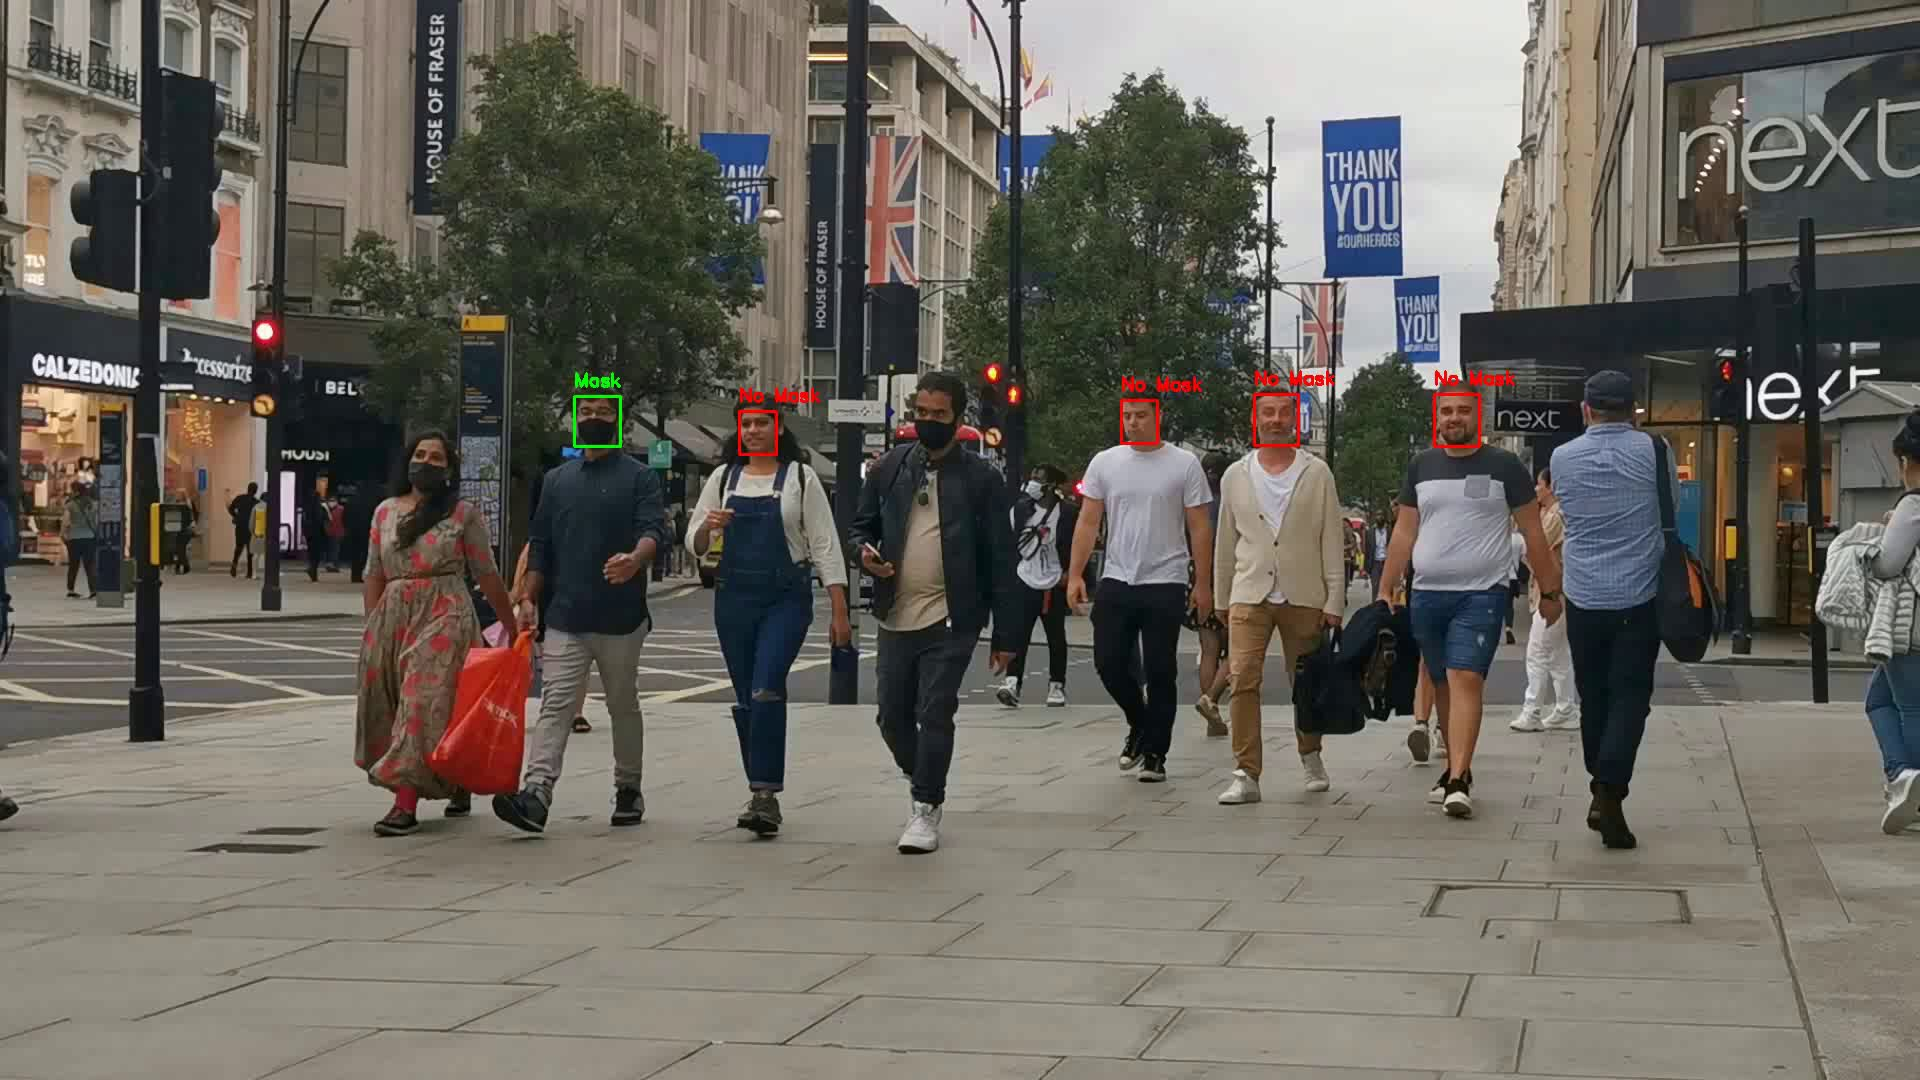

In [15]:
import cv2
from IPython.display import Image, display
import os

video_path = "outputs/mask_out.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite("outputs/mask_frame.jpg", frame)
    display(Image(filename="outputs/mask_frame.jpg"))
else:
    print(" No frame found in the output video.")

# Reading the results table (CSV)

In [16]:
import pandas as pd

csv_path = "outputs/mask_stats.csv"
df = pd.read_csv(csv_path)
display(df.head(10)) 

,Frame,Total_Faces,Mask,No_Mask,Mask_Percentage
0,1,5,1,4,20.00
1,2,5,1,4,20.00
2,3,5,1,4,20.00
3,4,5,1,4,20.00
4,5,7,3,4,42.86
5,6,7,2,5,28.57
6,7,6,2,4,33.33
7,8,5,1,4,20.00
8,9,6,2,4,33.33
9,10,6,2,4,33.33


# Chart of results

Text(0, 0.5, 'Count')

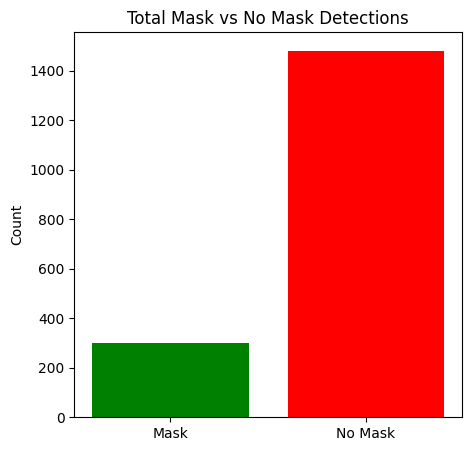

In [17]:
import matplotlib.pyplot as plt

mask_total = df["Mask"].sum()
no_mask_total = df["No_Mask"].sum()

plt.figure(figsize=(5,5))
plt.bar(["Mask", "No Mask"], [mask_total, no_mask_total], color=["green", "red"])
plt.title("Total Mask vs No Mask Detections")
plt.ylabel("Count")

###  Social Distance Detection

```markdown
## Social Distance Detection

This section evaluates social distancing compliance.  

- **Model:** `yolov8m.pt`  
- **Functionality:** Measures distance between detected humans and flags violations.


In [18]:
import os
import cv2
import math
import csv
from ultralytics import YOLO
import argparse

In [19]:
source = "videos/sample3.mp4"
output_path = "outputs/distance_out.mp4"
min_distance_px = 150
use_cm = False
view = True
csv_path = "outputs/distances.csv"

In [20]:
def ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def draw_box(frame, x1, y1, x2, y2, color=(0,255,0)):
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

def draw_line(frame, pt1, pt2, color=(0,0,255), text=None):
    cv2.line(frame, pt1, pt2, color, 2)
    if text:
        mid = ((pt1[0]+pt2[0])//2, (pt1[1]+pt2[1])//2)
        cv2.putText(frame, text, mid, cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

def get_center(box):
    x1, y1, x2, y2 = box
    return (int((x1+x2)/2), int((y1+y2)/2))

In [21]:
def check_violations(boxes, min_distance_px=150, use_cm=False):
    violations = set()
    n = len(boxes)
    centers = [get_center(b) for b in boxes]
    heights = [abs(b[3]-b[1]) for b in boxes]
    closest_pairs = []

    for i in range(n):
        min_dist = float('inf')
        closest_j = -1
        for j in range(n):
            if i == j:
                continue
            dx = centers[i][0] - centers[j][0]
            dy = centers[i][1] - centers[j][1]
            dist_px = math.sqrt(dx*dx + dy*dy)

            dist_display = dist_px

            if use_cm:
                h_avg_px = (heights[i] + heights[j]) / 2
                if h_avg_px > 0:
                    px_per_cm = h_avg_px / 170.0  
                    dist_display = dist_px / px_per_cm

            if dist_display < min_dist:
                min_dist = dist_display
                closest_j = j

        if closest_j >= 0:
            violation = min_dist < min_distance_px
            if violation:
                violations.add(i)
                violations.add(closest_j)
            closest_pairs.append((i, closest_j, min_dist, min_distance_px))

    return closest_pairs, violations

In [22]:
def run_video(source, output_path, min_distance_px=150, use_cm=False, view=False, csv_path=None):
    person_model = YOLO("models/yolov8m.pt")
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open {source}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0

    ensure_dir(os.path.dirname(output_path) or ".")
    ensure_dir(os.path.dirname(csv_path) or ".")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width,height))

    if csv_path:
        csv_file = open(csv_path, mode='w', newline='')
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(["frame", "person_id", "closest_person_id", "distance", "threshold", "violation"])

    frame_id = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_id += 1

        results = person_model(frame)[0]
        boxes = []
        for box, cls in zip(results.boxes.xyxy.cpu().numpy(), results.boxes.cls.cpu().numpy()):
            if int(cls)==0:
                boxes.append([int(box[0]), int(box[1]), int(box[2]), int(box[3])])

        closest_pairs, violations = check_violations(boxes, min_distance_px, use_cm)

        for idx, b in enumerate(boxes):
            color = (0,0,255) if idx in violations else (0,255,0)
            draw_box(frame, *b, color=color)

        for i, j, dist, threshold in closest_pairs:
            color = (0,255,0) if dist >= threshold else (0,0,255)
            text = f"{dist:.0f}" + ("cm" if use_cm else "px")
            draw_line(frame, get_center(boxes[i]), get_center(boxes[j]), color, text)
            if csv_path:
                violation = "Yes" if dist < threshold else "No"
                csv_writer.writerow([frame_id, i, j, round(dist,1), round(threshold,1), violation])

        writer.write(frame)
        if view:
            cv2.imshow("Social Distance", frame)
            if cv2.waitKey(1) & 0xFF==ord('q'):
                break

    cap.release()
    writer.release()
    if csv_path:
        csv_file.close()
    if view:
        cv2.destroyAllWindows()

    print(f"Video saved to: {output_path}")
    if csv_path:
        print(f"CSV saved to: {csv_path}")

In [23]:
!python social_distance/distance_estimator.py --source "videos/sample2.mp4" --out "outputs/distance_out.mp4" --view


0: 384x640 34 persons, 1 handbag, 244.9ms
Speed: 3.2ms preprocess, 244.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 1 handbag, 238.0ms
Speed: 3.8ms preprocess, 238.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 1 handbag, 222.5ms
Speed: 2.1ms preprocess, 222.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 34 persons, 1032.9ms
Speed: 2.7ms preprocess, 1032.9ms inference, 10.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 1 backpack, 2723.1ms
Speed: 19.5ms preprocess, 2723.1ms inference, 8.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 1259.0ms
Speed: 22.0ms preprocess, 1259.0ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 34 persons, 290.1ms
Speed: 4.5ms preprocess, 290.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 33 persons, 2 handbags, 

# Show an image from the resulting video

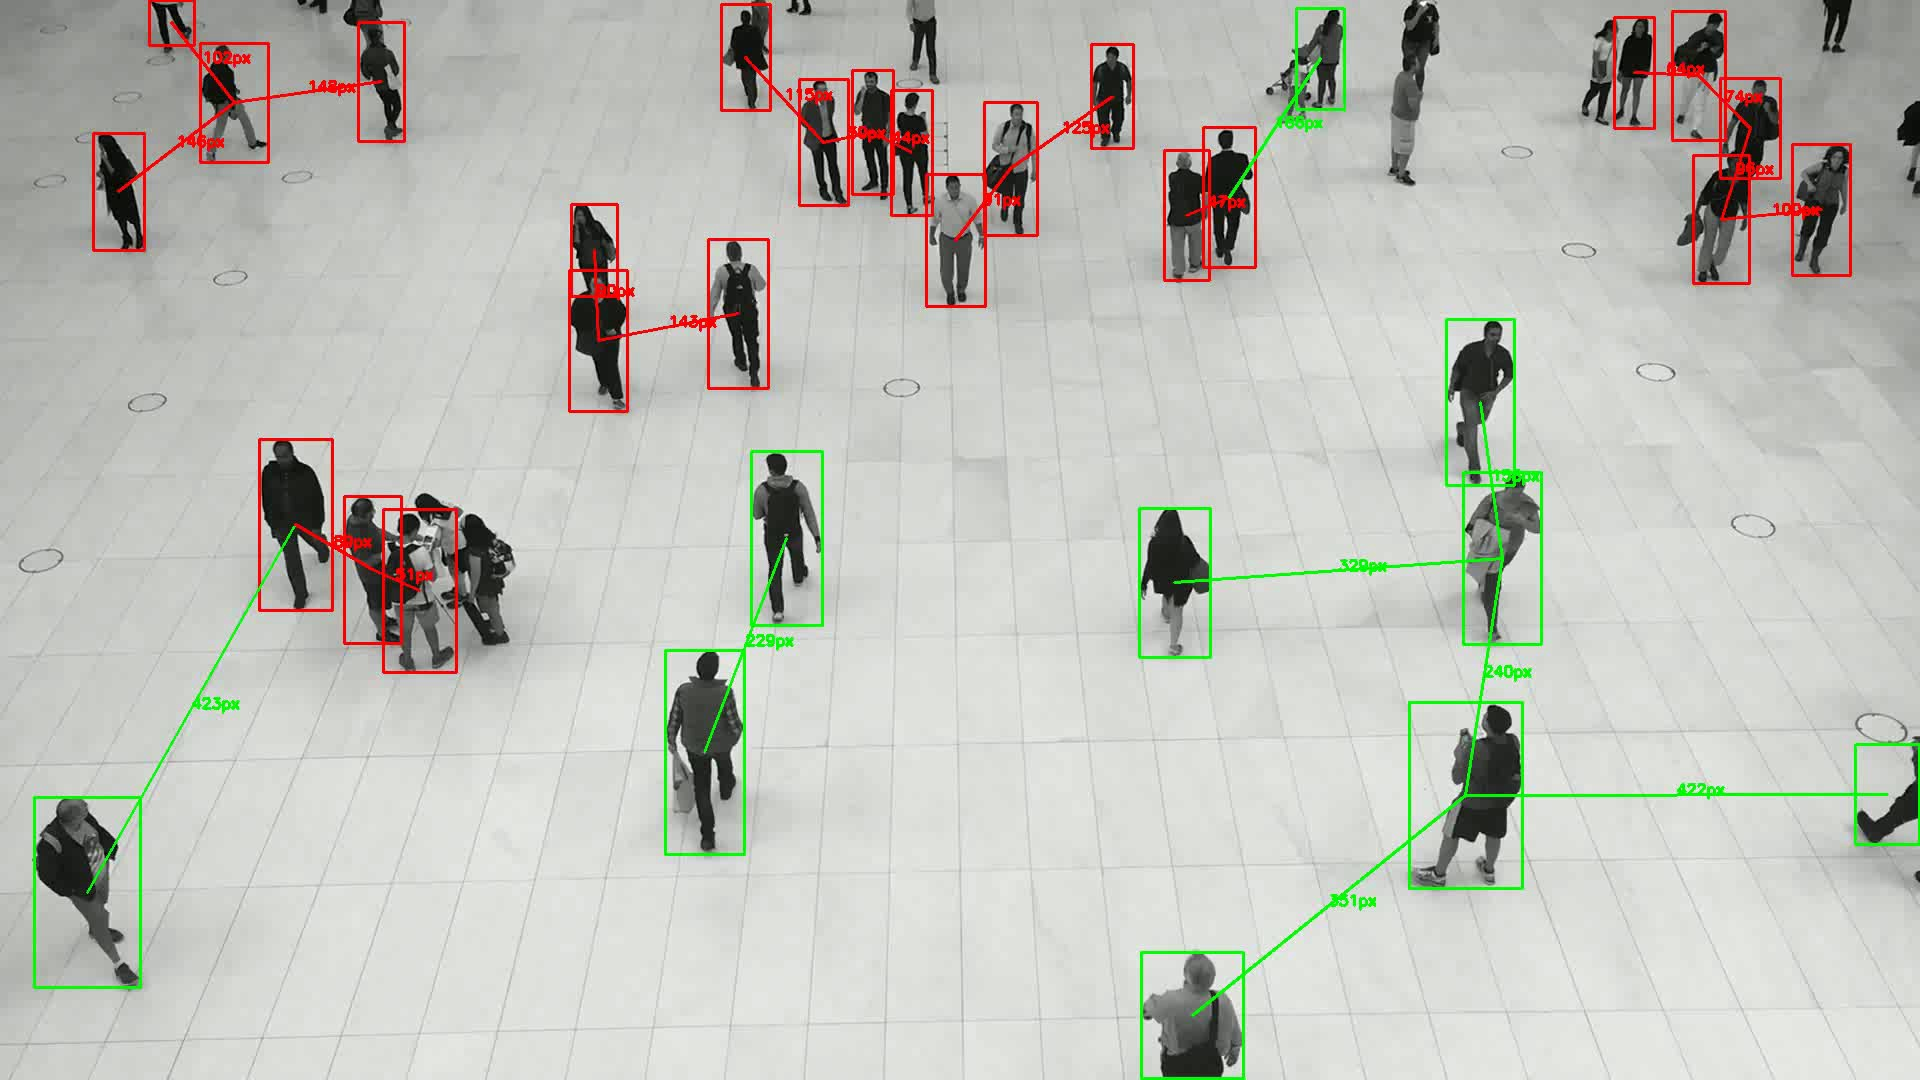

In [24]:
import cv2
from IPython.display import Image, display
import os

video_path = "outputs/distance_out.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if ret:
    cv2.imwrite("outputs/distance_frame.jpg", frame)
    display(Image(filename="outputs/distance_frame.jpg"))
else:
    print(" No frame found in the output video.")

# Reading the results table (CSV)

In [25]:
import pandas as pd

csv_path = "outputs/distances.csv"
df = pd.read_csv(csv_path)
display(df.head(10))

,frame,person_id,closest_person_id,distance,threshold,violation
0,1,0,3,350.6,150,No
1,1,1,7,422.7,150,No
2,1,2,6,229.2,150,No
3,1,3,15,239.9,150,No
4,1,4,15,157.5,150,No
5,1,5,29,101.8,150,Yes
6,1,6,2,229.2,150,No
7,1,7,21,89.2,150,Yes
8,1,8,24,90.6,150,Yes
9,1,9,15,328.9,150,No


# Chart of the number of violations

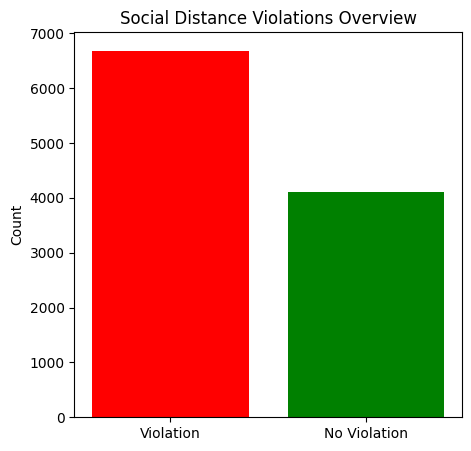

In [26]:
import matplotlib.pyplot as plt

violations = (df["violation"] == "Yes").sum()
non_violations = (df["violation"] == "No").sum()

plt.figure(figsize=(5,5))
plt.bar(["Violation", "No Violation"], [violations, non_violations], color=["red", "green"])
plt.title("Social Distance Violations Overview")
plt.ylabel("Count")
plt.show()

In [27]:
import cv2
from ultralytics import YOLO
import numpy as np
import os
import csv

In [28]:
MODEL_DIR = "models"

PERSON_MODEL = os.path.join(MODEL_DIR, "yolov8n_person.pt")
FACE_MODEL = os.path.join(MODEL_DIR, "face_yolov8n.pt")
MASK_MODEL = "runs/detect/train_new50/weights/last.pt"

DISTANCE_THRESHOLD_CM = 150  

person_model = YOLO(PERSON_MODEL)
face_model = YOLO(FACE_MODEL)
mask_model = YOLO(MASK_MODEL)

VIDEOS = [
    "videos/test1.mp4",
    "videos/test2.mp4",
    "videos/test3.mp4"
]

REAL_DIMENSIONS = [(400, 300), (400, 300), (400, 300)]

In [29]:
PTS_SRC_LIST = [
    np.array([[23, 417], [760, 411], [446, 210], [216, 212]], dtype=np.float32),  # v1
    np.array([[4, 418], [765, 408], [413, 159], [301, 156]], dtype=np.float32),   # v2
    np.array([[10, 425], [760, 421], [486, 227], [266, 225]], dtype=np.float32)   # v3
]

In [30]:
def box_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

In [ ]:
SUMMARY_CSV = "outputs/summary.csv"
with open(SUMMARY_CSV, mode='w', newline='', encoding='utf-8') as summary_file:
    summary_writer = csv.writer(summary_file)
    summary_writer.writerow(["Video", "Distance Violations", "Mask Violations", "Protocol Violators"])

    for idx, VIDEO_INPUT in enumerate(VIDEOS):
        VIDEO_NAME = os.path.basename(VIDEO_INPUT)
        VIDEO_OUTPUT = f"outputs/final_{VIDEO_NAME}"
        CSV_OUTPUT = VIDEO_OUTPUT.replace(".mp4", ".csv")

        cap = cv2.VideoCapture(VIDEO_INPUT)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        out = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

        csv_file = open(CSV_OUTPUT, mode='w', newline='', encoding='utf-8')
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(["Frame", "Person_ID", "Center_X", "Center_Y", "Nearest_Person", "Distance_cm"])

        pts_src = PTS_SRC_LIST[idx]
        real_width_cm, real_height_cm = REAL_DIMENSIONS[idx]
        pixel_width = max(pts_src[:,0]) - min(pts_src[:,0])
        pixel_height = max(pts_src[:,1]) - min(pts_src[:,1])
        scale_x = real_width_cm / pixel_width
        scale_y = real_height_cm / pixel_height
        scale = (scale_x + scale_y) / 2

        frame_idx = 0
        distance_violators = set()
        mask_violators = set()

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_idx += 1

            person_results = person_model(frame)[0]
            person_boxes = [box.cpu().numpy() for i, box in enumerate(person_results.boxes.xyxy) if int(person_results.boxes.cls[i])==0]

            face_results = face_model(frame)[0]
            face_boxes = [box.cpu().numpy() for box in face_results.boxes.xyxy]

            mask_results = mask_model(frame)[0]
            mask_boxes = [box.cpu().numpy() for box in mask_results.boxes.xyxy]
            mask_status = [int(cls) for cls in mask_results.boxes.cls]

            for face_id, face_box in enumerate(face_boxes):
                x1, y1, x2, y2 = map(int, face_box)
                is_no_mask = False
                for i, mask_box in enumerate(mask_boxes):
                    if box_iou(face_box, mask_box) > 0.2 and mask_status[i] == 1:
                        is_no_mask = True
                        mask_violators.add(face_id)
                        break
                color = (0,0,255) if is_no_mask else (0,255,0)
                label = "No Mask" if is_no_mask else "Mask"
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, label, (x1, y2+15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

            centers = []
            for box in person_boxes:
                x1, y1, x2, y2 = box
                cx = (x1 + x2)/2
                cy = (y1 + y2)/2
                centers.append((cx, cy))

            for i, center_i in enumerate(centers):
                min_dist = float('inf')
                nearest_j = -1
                for j, center_j in enumerate(centers):
                    if i == j:
                        continue
                    dx = center_i[0] - center_j[0]
                    dy = center_i[1] - center_j[1]
                    dist_pixel = np.sqrt(dx**2 + dy**2)
                    dist_cm = dist_pixel * scale
                    if dist_cm < min_dist:
                        min_dist = dist_cm
                        nearest_j = j

                if nearest_j != -1:
                    if min_dist < DISTANCE_THRESHOLD_CM:
                        distance_violators.add(i)

                    x1c = int((person_boxes[i][0]+person_boxes[i][2])/2)
                    y1c = int((person_boxes[i][1]+person_boxes[i][3])/2)
                    x2c = int((person_boxes[nearest_j][0]+person_boxes[nearest_j][2])/2)
                    y2c = int((person_boxes[nearest_j][1]+person_boxes[nearest_j][3])/2)

                    color = (0,255,0) if min_dist >= DISTANCE_THRESHOLD_CM else (0,0,255)
                    cv2.line(frame, (x1c,y1c), (x2c,y2c), color, 2)
                    cv2.putText(frame, f"{int(min_dist)} cm", ((x1c+x2c)//2, (y1c+y2c)//2),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

                    csv_writer.writerow([frame_idx, i, int(center_i[0]), int(center_i[1]), nearest_j, int(min_dist)])

            cv2.imshow("Mask & Distance Detection", frame)
            out.write(frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        protocol_violators = distance_violators.union(mask_violators)
        summary_writer.writerow([VIDEO_NAME, len(distance_violators), len(mask_violators), len(protocol_violators)])
        print(f"{VIDEO_NAME}: Distance={len(distance_violators)}, Mask={len(mask_violators)}, Protocol={len(protocol_violators)}")

        cap.release()
        out.release()
        csv_file.close()

cv2.destroyAllWindows()


In [34]:
!python multi_model_mask_distance.py


0: 384x640 10 Personas, 65.4ms
Speed: 2.9ms preprocess, 65.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 faces, 45.3ms
Speed: 5.5ms preprocess, 45.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 without_masks, 129.4ms
Speed: 3.2ms preprocess, 129.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 Personas, 45.6ms
Speed: 3.7ms preprocess, 45.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 faces, 45.2ms
Speed: 2.5ms preprocess, 45.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 without_masks, 103.9ms
Speed: 2.6ms preprocess, 103.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 Personas, 45.1ms
Speed: 3.2ms preprocess, 45.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 faces, 43.4ms
Speed: 2.6ms preprocess, 43.4ms inference, 0.9ms postprocess 

# Show the first frame of each video

 final_test1_frame.jpg


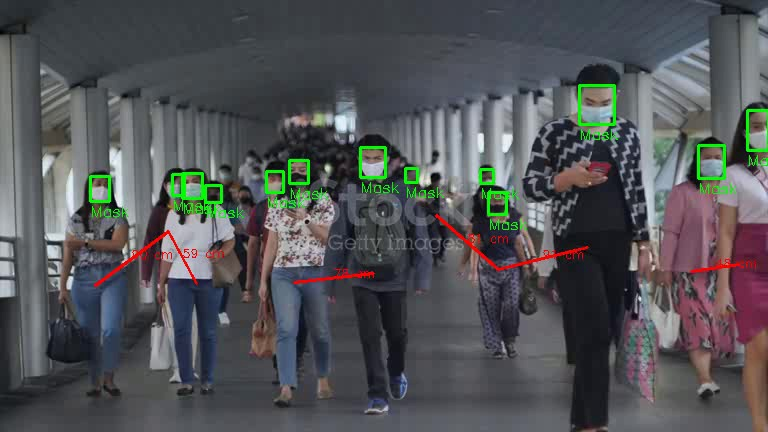

 final_test2_frame.jpg


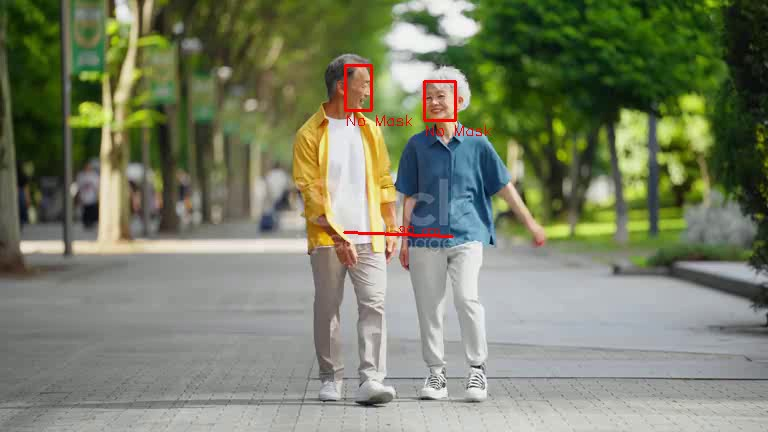

 final_test3_frame.jpg


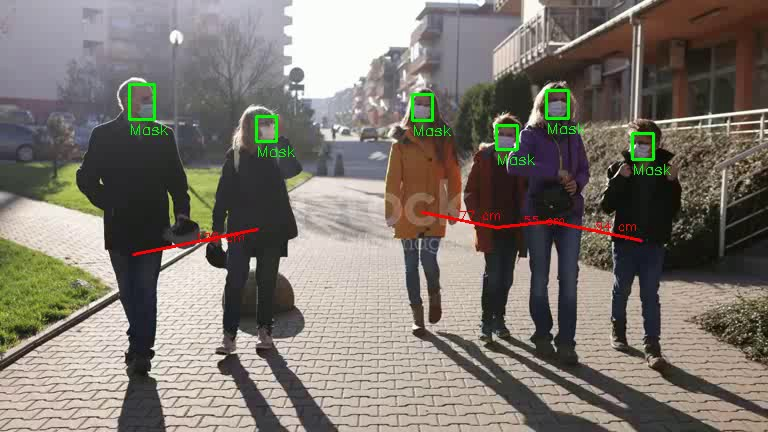

In [35]:
import cv2
from IPython.display import Image, display
import os

VIDEOS = [
    "outputs/final_test1.mp4",
    "outputs/final_test2.mp4",
    "outputs/final_test3.mp4"
]

for video_path in VIDEOS:
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if ret:
        frame_file = video_path.replace(".mp4", "_frame.jpg")
        cv2.imwrite(frame_file, frame)
        print(f" {os.path.basename(frame_file)}")
        display(Image(filename=frame_file))
    else:
        print(f" No frame found in {video_path}")

# Reading and displaying CSV for each video

In [36]:
import pandas as pd

CSV_FILES = [
    "outputs/final_test1.csv",
    "outputs/final_test2.csv",
    "outputs/final_test3.csv"
]

for csv_path in CSV_FILES:
    df = pd.read_csv(csv_path)
    print(f"Showing first 10 rows for {os.path.basename(csv_path)}")
    display(df.head(10))

Showing first 10 rows for final_test1.csv


,Frame,Person_ID,Center_X,Center_Y,Nearest_Person,Distance_cm
0,1,0,95,285,9,90
1,1,1,587,247,2,91
2,1,2,498,269,8,81
3,1,3,373,273,5,78
4,1,4,691,271,7,48
5,1,5,294,282,3,78
6,1,6,196,283,9,59
7,1,7,739,264,4,48
8,1,8,436,215,2,81
9,1,9,168,231,6,59


Showing first 10 rows for final_test2.csv


,Frame,Person_ID,Center_X,Center_Y,Nearest_Person,Distance_cm
0,1,0,344,232,1,90
1,1,1,452,236,0,90
2,2,0,462,237,1,97
3,2,1,345,233,0,97
4,3,0,456,238,1,91
5,3,1,347,233,0,91
6,4,0,448,240,1,82
7,4,1,349,232,0,82
8,5,0,448,239,1,81
9,5,1,351,231,0,81


Showing first 10 rows for final_test3.csv


,Frame,Person_ID,Center_X,Center_Y,Nearest_Person,Distance_cm
0,1,0,550,221,4,55
1,1,1,133,254,3,128
2,1,2,641,240,0,94
3,1,3,257,229,1,128
4,1,4,496,227,0,55
5,1,5,422,212,4,77
6,2,0,549,221,5,54
7,2,1,420,210,5,78
8,2,2,252,232,3,123
9,2,3,133,251,2,123


# Plotting violation statistics for each video

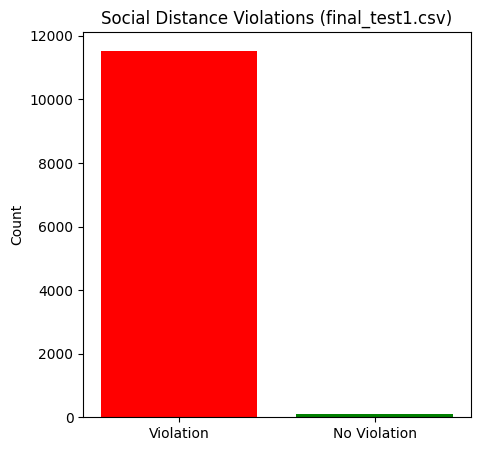

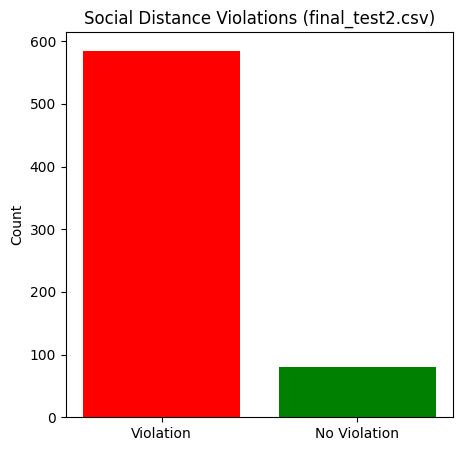

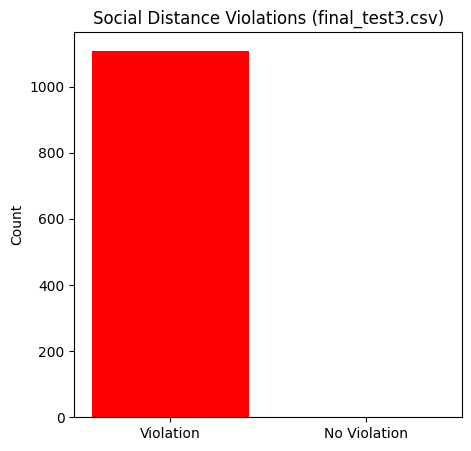

In [37]:
import matplotlib.pyplot as plt

for csv_path in CSV_FILES:
    df = pd.read_csv(csv_path)
    violations = (df["Distance_cm"] < 150).sum()
    non_violations = len(df) - violations

    plt.figure(figsize=(5,5))
    plt.bar(["Violation", "No Violation"], [violations, non_violations], color=["red", "green"])
    plt.title(f"Social Distance Violations ({os.path.basename(csv_path)})")
    plt.ylabel("Count")
    plt.show()